# HydraMultiRocketPlus

Model iz knjižnice **tsai** (https://timeseriesai.github.io/tsai/models.hydramultirocketplus.html)

       tsai 0.4.1., Python 3.12, torch 2.7.1


## A. NATOPS
   - skup podataka za klasifikaciju gesti u **6 klasa** temeljen na signalima pokreta ruku zabilježenima senzorima
   - **24 kanala**, **51 vremenski korak**
  - srednje težak skup

Train size: 180
Test size: 180
Shape: (360, 24, 51)
Classes: ['1.0' '2.0' '3.0' '4.0' '5.0' '6.0']


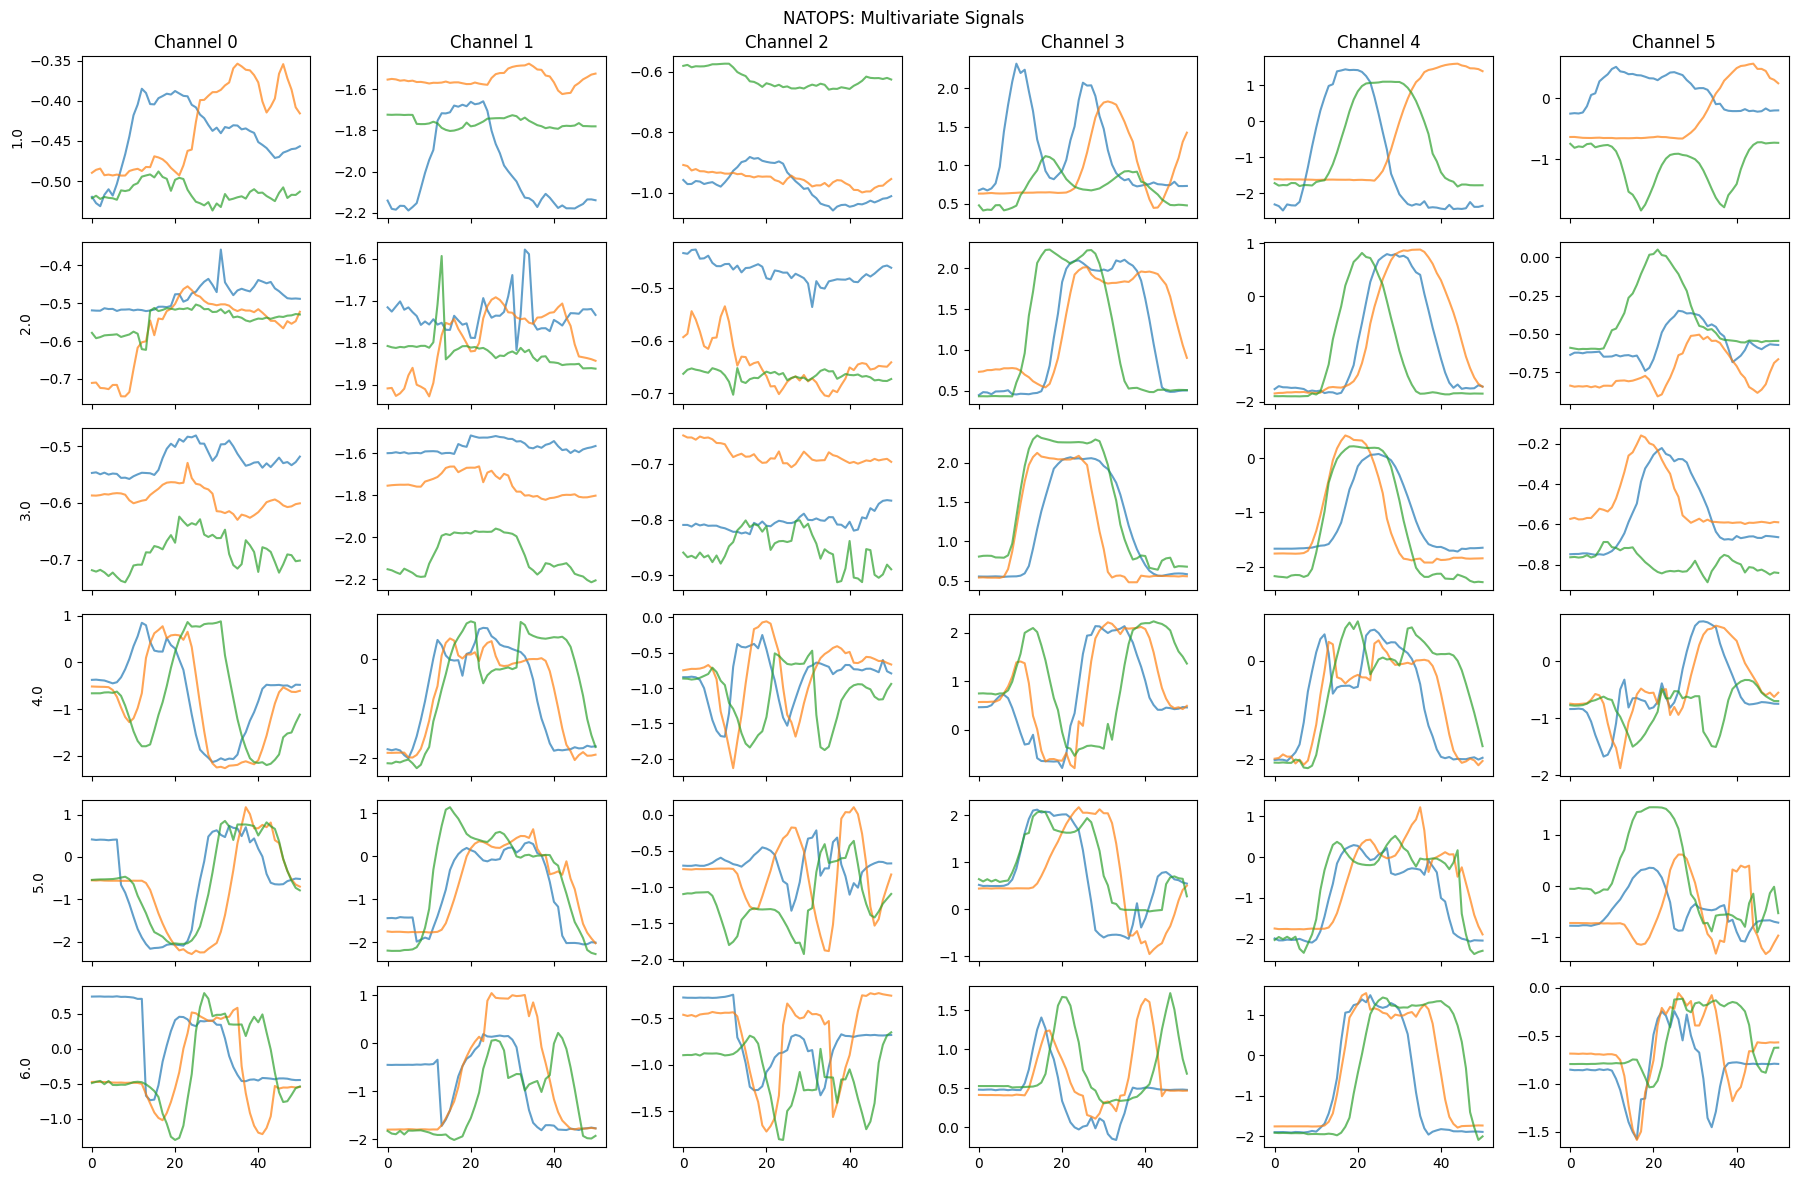

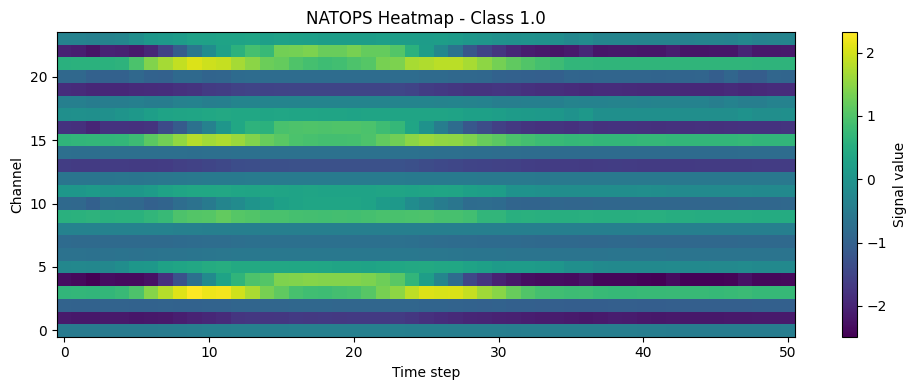

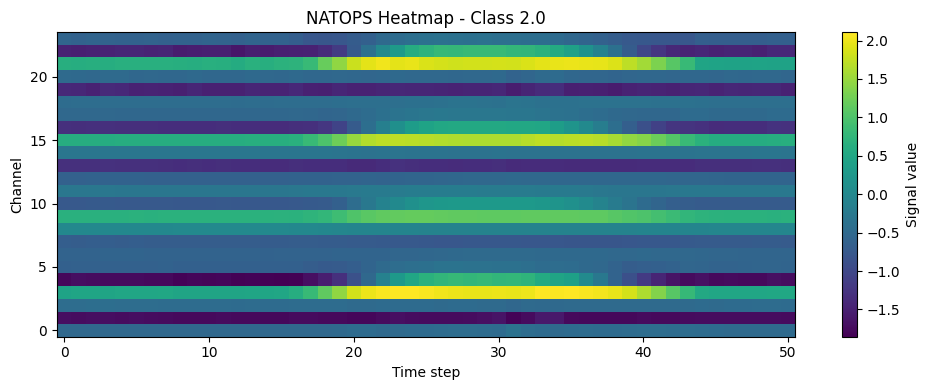

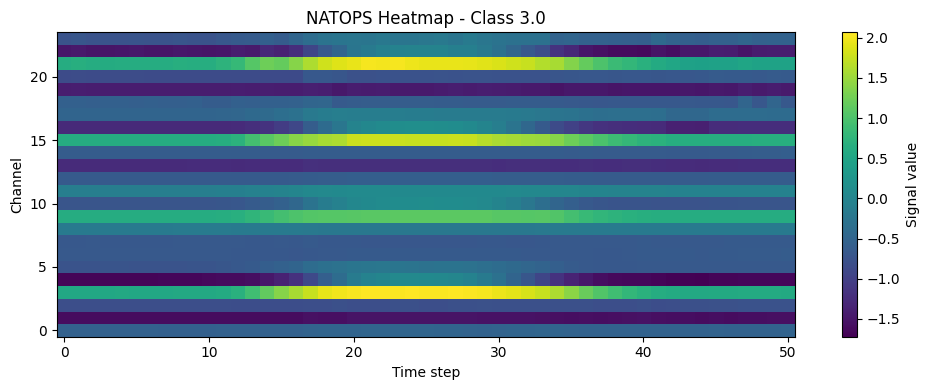

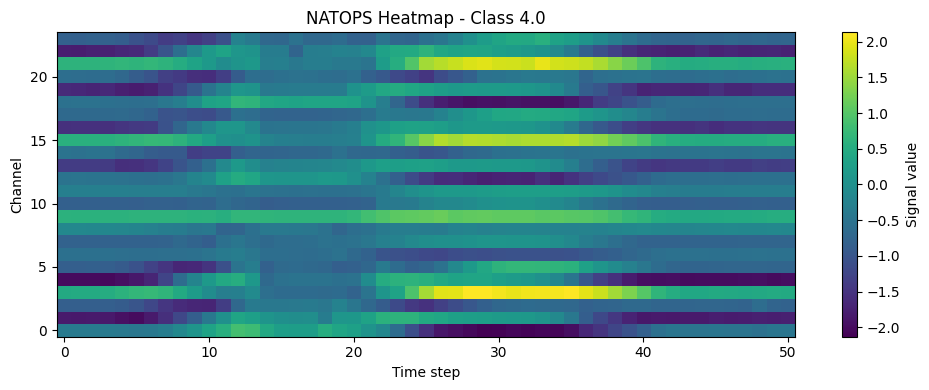

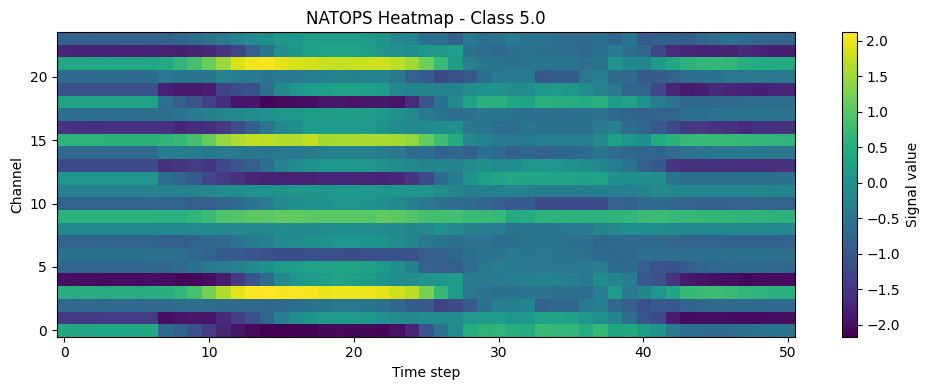

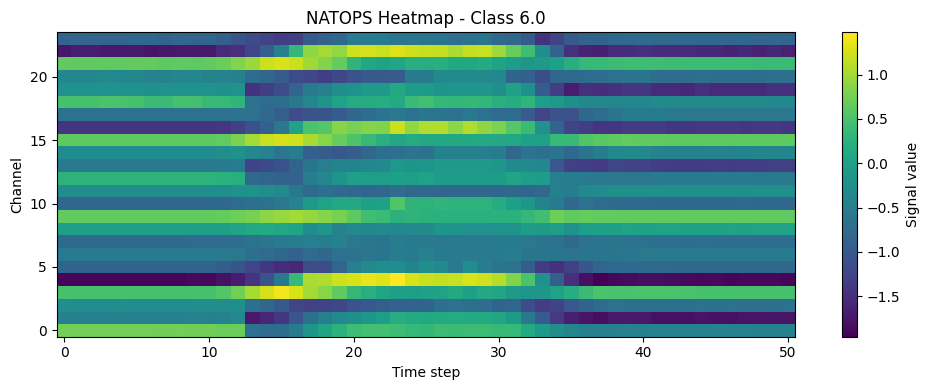

In [1]:
from tsai.all import *
from sklearn.preprocessing import StandardScaler
import numpy as np

#reproducibility
set_seed(42, reproducible=True)


ds_name = 'NATOPS'

X, y, splits = get_UCR_data(ds_name, return_split=False)

train_idx, test_idx = splits

print("Train size:", len(train_idx))
print("Test size:", len(test_idx))

print("Shape:", X.shape)
print("Classes:", np.unique(y))

classes = np.unique(y)


#visualization helpers
def plot_multivariate_examples(X_data, title):

    n_channels_to_show = 6

    fig, axes = plt.subplots(
        len(classes),
        n_channels_to_show,
        figsize=(18, 12),
        sharex=True
    )

    for row, cls in enumerate(classes):

        idxs = np.where(y == cls)[0][:3]

        for ch in range(n_channels_to_show):

            for idx in idxs:
                axes[row, ch].plot(X_data[idx, ch], alpha=0.7)

            if row == 0:
                axes[row, ch].set_title(f'Channel {ch}')

            if ch == 0:
                axes[row, ch].set_ylabel(cls)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_heatmaps(X_data, title_prefix):

    for cls in classes:

        idx = np.where(y == cls)[0][0]

        plt.figure(figsize=(10, 4))

        plt.imshow(
            X_data[idx],
            aspect='auto',
            cmap='viridis',
            origin='lower'
        )

        plt.colorbar(label='Signal value')

        plt.title(f'{title_prefix} - Class {cls}')
        plt.xlabel('Time step')
        plt.ylabel('Channel')

        plt.tight_layout()
        plt.show()

plot_multivariate_examples(
    X,
    "NATOPS: Multivariate Signals"
)

plot_heatmaps(
    X,
    "NATOPS Heatmap"
)



epoch,train_loss,valid_loss,accuracy,time
0,1.469065,1.276458,0.400000,00:01
1,1.012582,0.902587,0.627778,00:01
2,0.874188,0.627704,0.772222,00:01
3,0.742825,0.564455,0.755556,00:01
4,0.637718,0.592294,0.805556,00:01
5,0.592688,0.383913,0.822222,00:01
6,0.563008,0.303519,0.855556,00:01
7,0.497186,0.292248,0.855556,00:01
8,0.432787,0.323199,0.855556,00:01
9,0.381787,0.323516,0.855556,00:01


NATOPS accuracy: 0.86


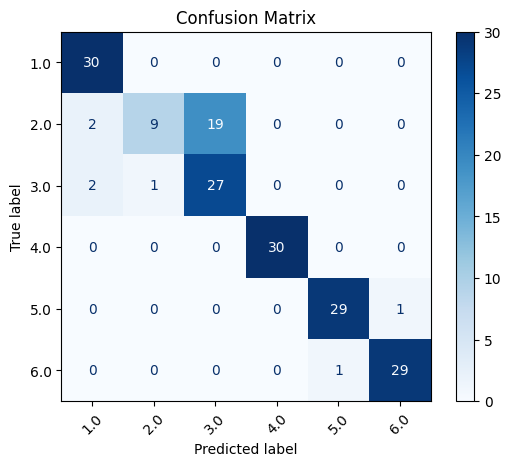

In [2]:
# TRAIN/EVAL

from tsai.all import *
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
import torch


# encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

dls = get_ts_dls(X, y_encoded, splits=splits)

model = HydraMultiRocketPlus(c_in=X.shape[1], c_out=len(np.unique(y)), seq_len=X.shape[2])

learn = Learner(dls, model, loss_func=CrossEntropyLossFlat(), metrics=accuracy)
learn.fit_one_cycle(10, 1e-3)

probs, targets = learn.get_preds()
preds = probs.argmax(dim=1)


loss, acc = learn.validate()
print(f"NATOPS accuracy: {acc:.2f}")

cm = confusion_matrix(targets, preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()



Uvodimo **z-skaliranje** (možda dobijemo bolji rezultat)

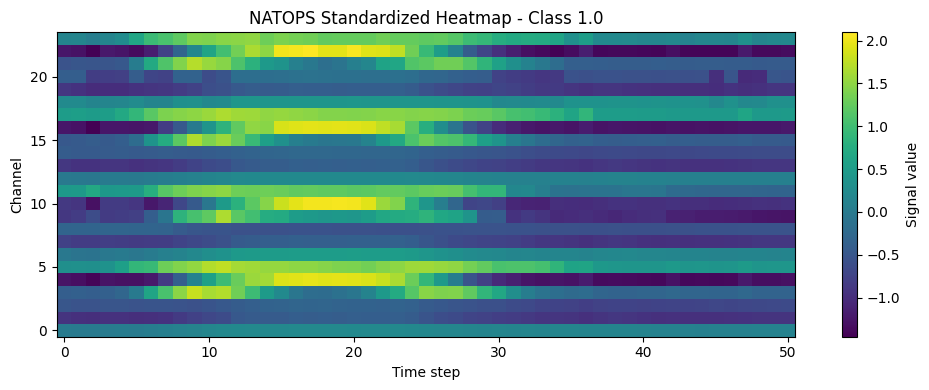

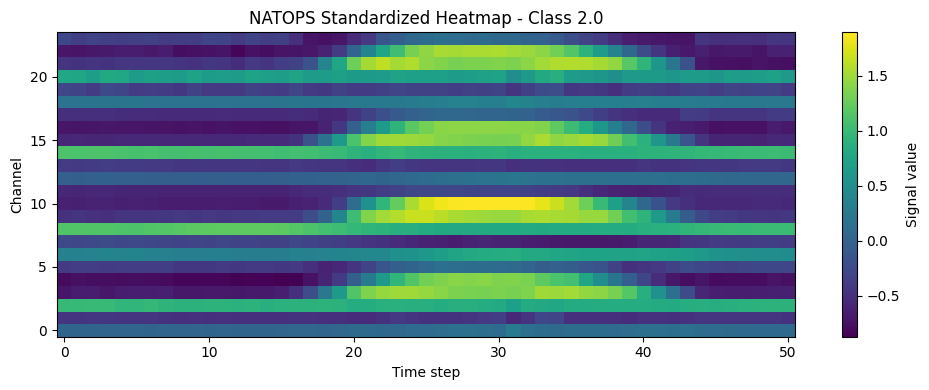

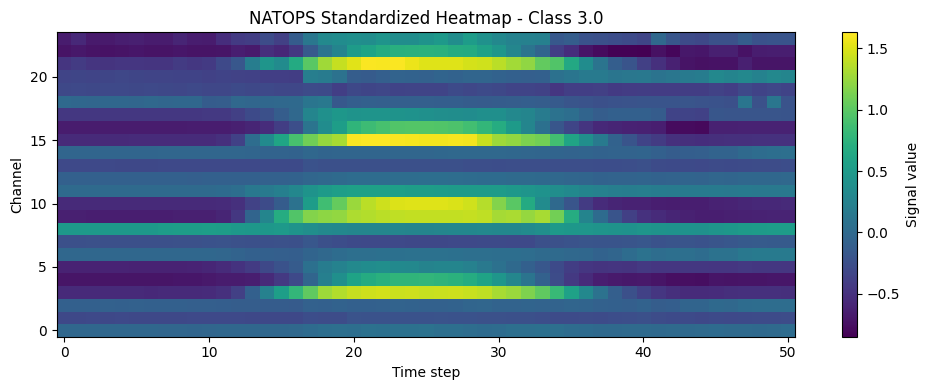

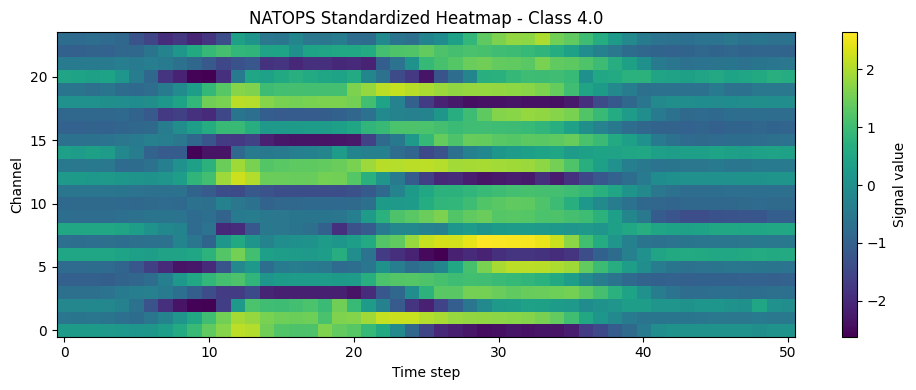

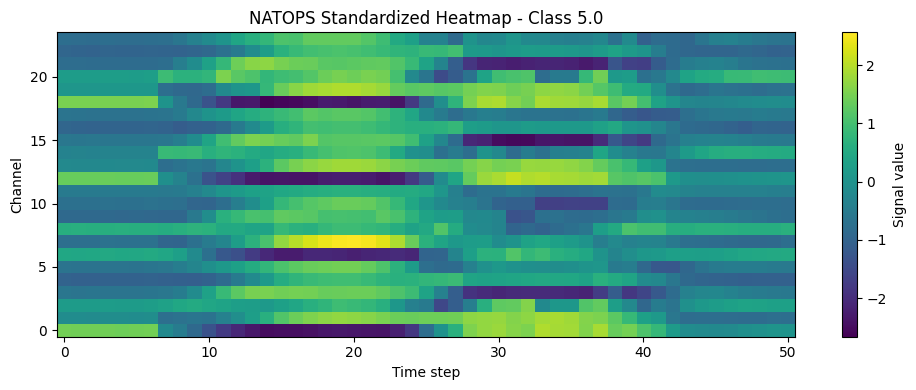

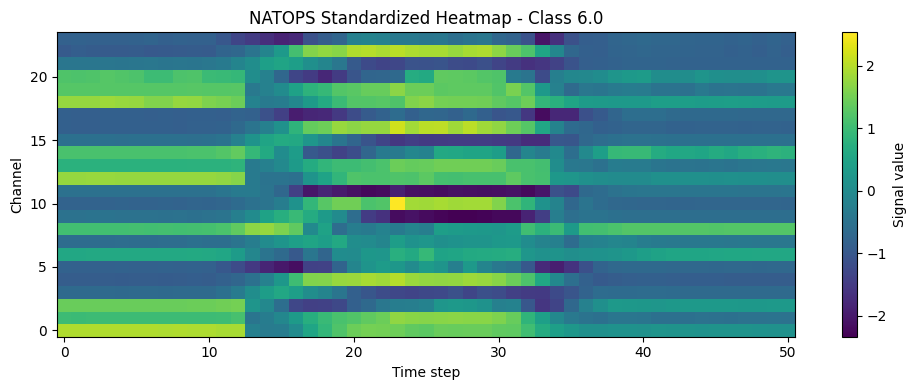

In [3]:
# moramo reshapeati oblike jer Standard scaler očekuje 2D matricu, a mi imamo 3D time series
X_train = X[train_idx]
X_test = X[test_idx]

scaler = StandardScaler()

X_train_2d = X_train.transpose(0, 2, 1).reshape(-1, X.shape[1])
X_test_2d = X_test.transpose(0, 2, 1).reshape(-1, X.shape[1])

# fit ONLY on train
X_train_scaled = scaler.fit_transform(X_train_2d)
X_test_scaled = scaler.transform(X_test_2d)

# reshape back
X_train_scaled = X_train_scaled.reshape(
    X_train.shape[0],
    X_train.shape[2],
    X_train.shape[1]
).transpose(0, 2, 1)

X_test_scaled = X_test_scaled.reshape(
    X_test.shape[0],
    X_test.shape[2],
    X_test.shape[1]
).transpose(0, 2, 1)

# reconstruct full scaled dataset
X_scaled = np.empty_like(X)

X_scaled[train_idx] = X_train_scaled
X_scaled[test_idx] = X_test_scaled

plot_heatmaps(
    X_scaled,
    "NATOPS Standardized Heatmap"
)



epoch,train_loss,valid_loss,accuracy,time
0,1.458572,1.701131,0.288889,00:00
1,0.957156,1.436552,0.494444,00:00
2,0.884107,0.918671,0.661111,00:00
3,0.700347,0.703338,0.738889,00:00
4,0.627208,0.599203,0.777778,00:00
5,0.549469,0.424593,0.844444,00:00
6,0.467240,0.523293,0.827778,00:00
7,0.427744,0.567779,0.816667,00:00
8,0.382038,0.509135,0.800000,00:00
9,0.346907,0.486467,0.800000,00:00


NATOPS accuracy: 0.80


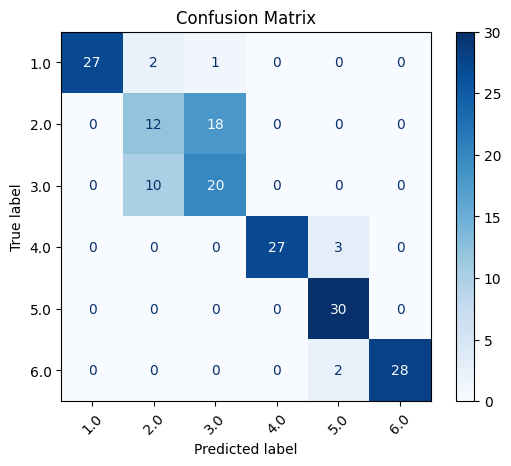

In [4]:

dls_scaled = get_ts_dls(X_scaled, y_encoded, splits=splits)

model_sc = HydraMultiRocketPlus(c_in=X.shape[1], c_out=len(np.unique(y)), seq_len=X.shape[2])

learn_sc = Learner(dls_scaled, model_sc, loss_func=CrossEntropyLossFlat(), metrics=accuracy)
learn_sc.fit_one_cycle(10, 1e-3)

probs_sc, targets_sc = learn_sc.get_preds()
preds_sc = probs_sc.argmax(dim=1)


loss, acc = learn_sc.validate()
print(f"NATOPS accuracy: {acc:.2f}")

cm = confusion_matrix(targets_sc, preds_sc)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

*Nismo dobili bolji rezultat, moguće da je amplituda zapravo korisna informacija. Vraćamo se na ne-skalirani*
**Nadalje se koristi ne-skalirani (raw) dataset.**

## Analiza i vizualizacije:

- Arhitektura
- Feature space
- Krivo klasificirani primjerci

In [5]:
print(learn.model)

HydraMultiRocketPlus(
  (backbone): HydraMultiRocketBackbonePlus(
    (hydra): HydraBackbonePlus()
    (multirocket): MultiRocketBackbonePlus(
      (branch_x): MultiRocketFeaturesPlus()
      (branch_x_diff): MultiRocketFeaturesPlus()
    )
  )
  (head): Sequential(
    (0): fastai.layers.Flatten(full=False)
    (1): BatchNorm1d(52800, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Linear(in_features=52800, out_features=6, bias=True)
  )
)


*Komentar:*

- Hydra branch: random convolutional feature extraction
- MultiRocket branch:
        - raw signal features (x)
        - first-difference features (branch_x_diff => x[t] - x[t-1])
- Linear classification head
    - BatchNorm1d(53824); Linear(53824 → 4) - feat. extractor stvara ogromni feat. vector

=> Snaga modela je u ogromnom broju featurea

### Feature space
- s obzirom da imamo ogroman broj naučenih featurea, radimo projekciju u 2D prostor: (t-sne-susjedi i UMAP-glob.struktura)

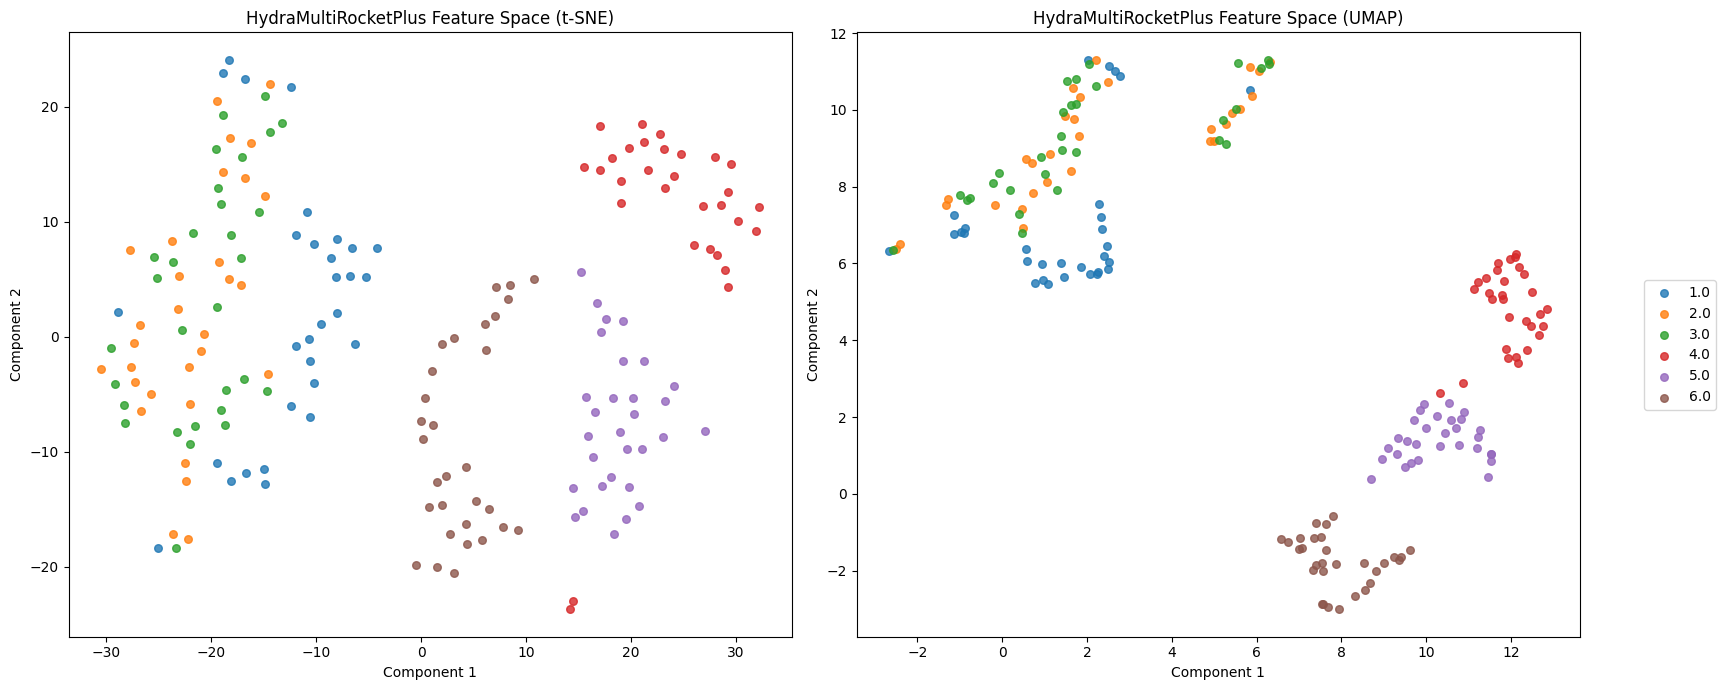

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import umap.umap_ as umap


features = []
targets = []

learn.model.eval()

with torch.no_grad():

    for xb, yb in dls.valid:

        feats = learn.model.backbone(xb)

        # flatten
        feats = feats.reshape(feats.shape[0], -1)

        features.append(feats.cpu().numpy())
        targets.append(yb.cpu().numpy())

features = np.concatenate(features)
targets = np.concatenate(targets)

z_tsne = TSNE(
    n_components=2,
    perplexity=15,
    learning_rate="auto",
    random_state=42
).fit_transform(features)


z_umap = umap.UMAP(
    n_components=2,
    n_neighbors=5,
    min_dist=0.25,
    metric="euclidean",
    random_state=42
).fit_transform(features)



fig, axes = plt.subplots(1, 2, figsize=(16, 7))


for cls in np.unique(targets):

    idx = targets == cls

    axes[0].scatter(
        z_tsne[idx, 0],
        z_tsne[idx, 1],
        s=30,
        alpha=0.8,
        label=le.inverse_transform([cls])[0]
    )

axes[0].set_title("HydraMultiRocketPlus Feature Space (t-SNE)")
axes[0].set_xlabel("Component 1")
axes[0].set_ylabel("Component 2")



for cls in np.unique(targets):

    idx = targets == cls

    axes[1].scatter(
        z_umap[idx, 0],
        z_umap[idx, 1],
        s=30,
        alpha=0.8,
        label=le.inverse_transform([cls])[0]
    )

axes[1].set_title("HydraMultiRocketPlus Feature Space (UMAP)")
axes[1].set_xlabel("Component 1")
axes[1].set_ylabel("Component 2")

# shared legend
handles, labels = axes[1].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center right",
    bbox_to_anchor=(1.08, 0.5)
)

plt.tight_layout()
plt.show()

*Vidimo da postoje zapravo dvije skupine gesti (1,2,3) i (4,5,6) i očekujemo više pogrešaka u prvoj skupini.*

### Krivo klasificirani
- pogledat ćemo confidence jer ako je mali conf, onda zapravo model nije siguran, a ako je veliki onda nije dobro naučio obuhvatiti takav primejrak

In [7]:
preds_np = np.array(preds.cpu())
targets_np = np.array(targets)

wrong_idx = np.where(preds_np != targets_np)[0]
print(f"Krivo klasificiranih: {len(wrong_idx)}")

for idx in wrong_idx:

    true_cls = le.inverse_transform([targets[idx].item()])[0]
    pred_cls = le.inverse_transform([preds[idx].item()])[0]

    confidence = probs[idx].max().item()

    print(
        f"Sample {idx} | "
        f"True: {true_cls} | "
        f"Predicted: {pred_cls} | "
        f"Confidence: {confidence:.3f}"
    )

Krivo klasificiranih: 26
Sample 14 | True: 2.0 | Predicted: 3.0 | Confidence: 0.789
Sample 24 | True: 2.0 | Predicted: 1.0 | Confidence: 0.664
Sample 26 | True: 2.0 | Predicted: 3.0 | Confidence: 0.818
Sample 28 | True: 2.0 | Predicted: 3.0 | Confidence: 0.556
Sample 42 | True: 2.0 | Predicted: 3.0 | Confidence: 0.947
Sample 43 | True: 6.0 | Predicted: 5.0 | Confidence: 0.990
Sample 55 | True: 2.0 | Predicted: 3.0 | Confidence: 0.549
Sample 64 | True: 2.0 | Predicted: 3.0 | Confidence: 0.622
Sample 66 | True: 2.0 | Predicted: 3.0 | Confidence: 0.825
Sample 69 | True: 2.0 | Predicted: 3.0 | Confidence: 0.863
Sample 84 | True: 2.0 | Predicted: 3.0 | Confidence: 0.680
Sample 90 | True: 5.0 | Predicted: 6.0 | Confidence: 0.650
Sample 96 | True: 2.0 | Predicted: 3.0 | Confidence: 0.848
Sample 111 | True: 2.0 | Predicted: 3.0 | Confidence: 0.730
Sample 112 | True: 2.0 | Predicted: 3.0 | Confidence: 0.667
Sample 114 | True: 2.0 | Predicted: 1.0 | Confidence: 0.819
Sample 119 | True: 2.0 | Pre

*Najviše je pogreški između 2 (palac gore) i 3 (palac dolje), kao što smo i očekivali. To je i objektivno težak problem jer je pokret minimalan, područje koje je relevatno (šaka) vrlo malo i razlika je samo u položaju palca.*

### Analiza nejasnih

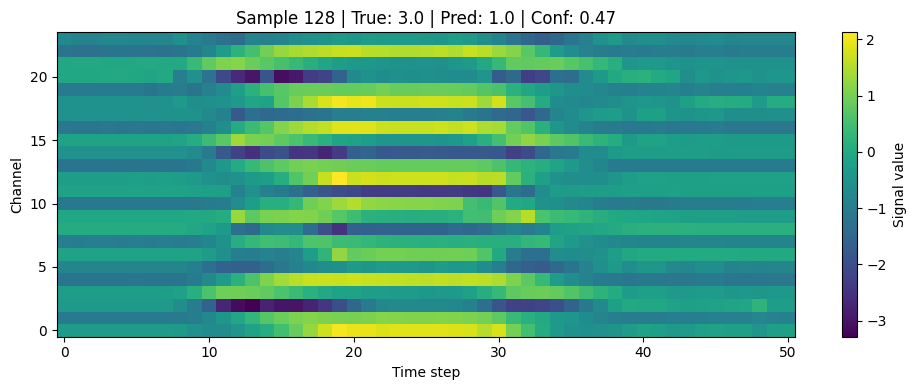

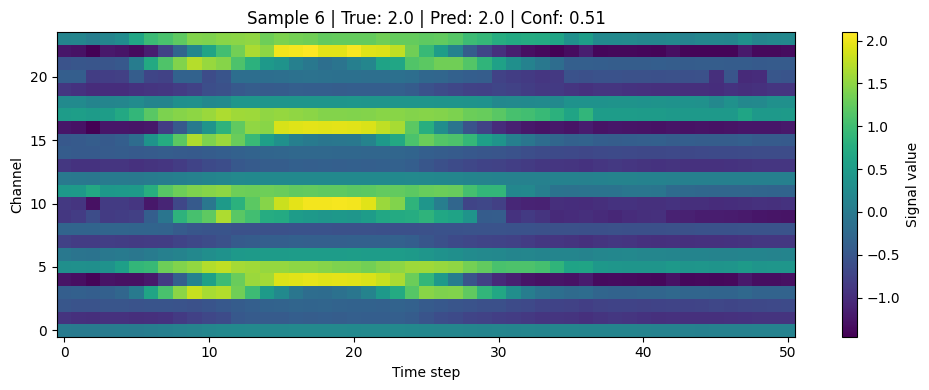

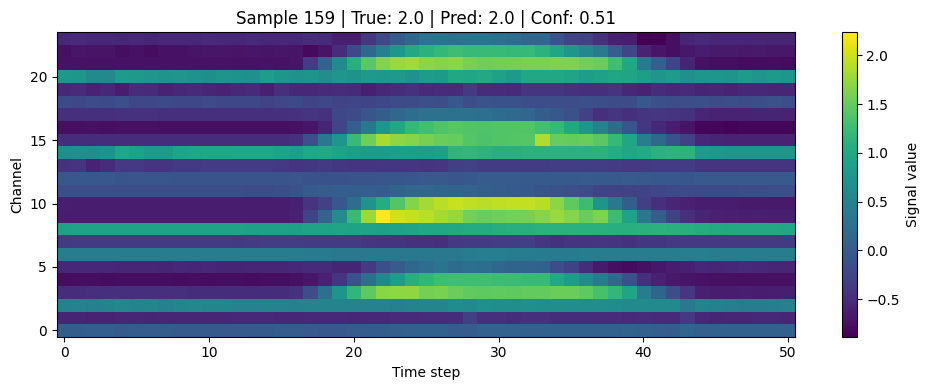

In [8]:
uncertainty = 1 - probs.max(dim=1).values.numpy()
hardest = np.argsort(-uncertainty)

wrong_conf = probs.max(dim=1).values.numpy()[wrong_idx]
confidently_wrong = wrong_idx[np.argsort(-wrong_conf)]

for idx in hardest[:3]:

    true_cls = le.inverse_transform([targets[idx].item()])[0]
    pred_cls = le.inverse_transform([preds[idx].item()])[0]

    confidence = probs[idx].max().item()

    plt.figure(figsize=(10,4))

    plt.imshow(
        X_scaled[idx],
        aspect='auto',
        cmap='viridis',
        origin='lower'
    )

    plt.colorbar(label='Signal value')

    plt.title(
        f"Sample {idx} | "
        f"True: {true_cls} | "
        f"Pred: {pred_cls} | "
        f"Conf: {confidence:.2f}"
    )

    plt.xlabel("Time step")
    plt.ylabel("Channel")

    plt.tight_layout()
    plt.show()


### Analiza uvjereno pogrešnih

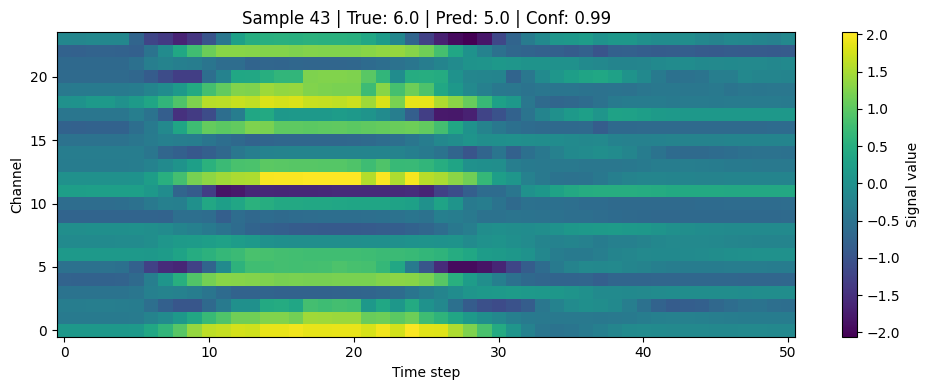

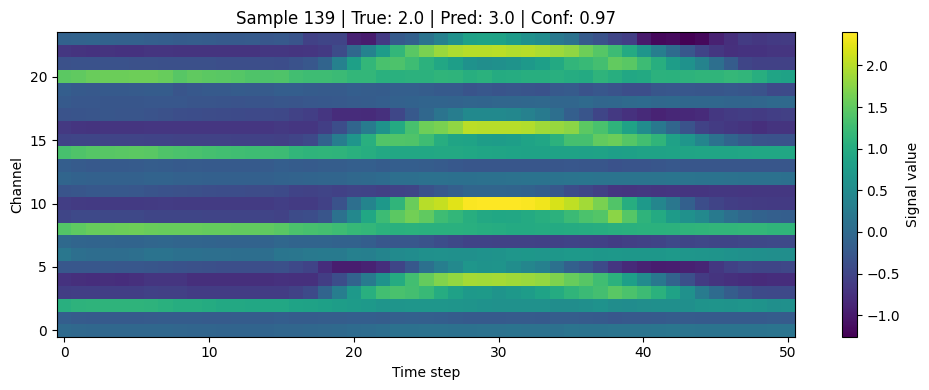

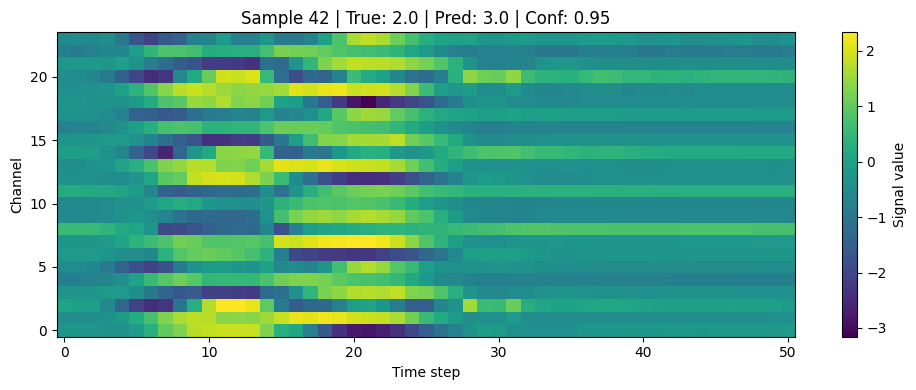

In [9]:
for idx in confidently_wrong[:3]:

    true_cls = le.inverse_transform([targets[idx].item()])[0]
    pred_cls = le.inverse_transform([preds[idx].item()])[0]

    confidence = probs[idx].max().item()

    plt.figure(figsize=(10,4))

    plt.imshow(
        X_scaled[idx],
        aspect='auto',
        cmap='viridis',
        origin='lower'
    )

    plt.colorbar(label='Signal value')

    plt.title(
        f"Sample {idx} | "
        f"True: {true_cls} | "
        f"Pred: {pred_cls} | "
        f"Conf: {confidence:.2f}"
    )

    plt.xlabel("Time step")
    plt.ylabel("Channel")

    plt.tight_layout()
    plt.show()

## Channel ablation

- The order of the data is as follows 1. Hand tip left, X coordinate 2. Hand tip left, Y coordinate 3. Hand tip left, Z coordinate 4. Hand tip right, X coordinate 5. Hand tip right, Y coordinate 6. Hand tip right, Z coordinate 7. Elbow left, X coordinate 8. Elbow left, Y coordinate 9. Elbow left, Z coordinate 10. Elbow right, X coordinate 11. Elbow right, Y coordinate 12. Elbow right, Z coordinate 13. Wrist left, X coordinate 14. Wrist left, Y coordinate 15. Wrist left, Z coordinate 16. Wrist right, X coordinate 17. Wrist right, Y coordinate 18. Wrist right, Z coordinate 19. Thumb left, X coordinate 20. Thumb left, Y coordinate 21. Thumb left, Z coordinate 22. Thumb right, X coordinate 23. Thumb right, Y coordinate 24. Thumb right, Z coordinate

Baseline accuracy: 0.8000
Channel 00 | Ablated acc: 0.8444 | Drop: -0.0444
Channel 01 | Ablated acc: 0.8333 | Drop: -0.0333
Channel 02 | Ablated acc: 0.8611 | Drop: -0.0611
Channel 03 | Ablated acc: 0.7889 | Drop: 0.0111
Channel 04 | Ablated acc: 0.8222 | Drop: -0.0222
Channel 05 | Ablated acc: 0.8333 | Drop: -0.0333
Channel 06 | Ablated acc: 0.8667 | Drop: -0.0667
Channel 07 | Ablated acc: 0.8556 | Drop: -0.0556
Channel 08 | Ablated acc: 0.8556 | Drop: -0.0556
Channel 09 | Ablated acc: 0.8500 | Drop: -0.0500
Channel 10 | Ablated acc: 0.8778 | Drop: -0.0778
Channel 11 | Ablated acc: 0.8500 | Drop: -0.0500
Channel 12 | Ablated acc: 0.8500 | Drop: -0.0500
Channel 13 | Ablated acc: 0.8611 | Drop: -0.0611
Channel 14 | Ablated acc: 0.8500 | Drop: -0.0500
Channel 15 | Ablated acc: 0.8389 | Drop: -0.0389
Channel 16 | Ablated acc: 0.8722 | Drop: -0.0722
Channel 17 | Ablated acc: 0.8333 | Drop: -0.0333
Channel 18 | Ablated acc: 0.8444 | Drop: -0.0444
Channel 19 | Ablated acc: 0.8444 | Drop: -0.

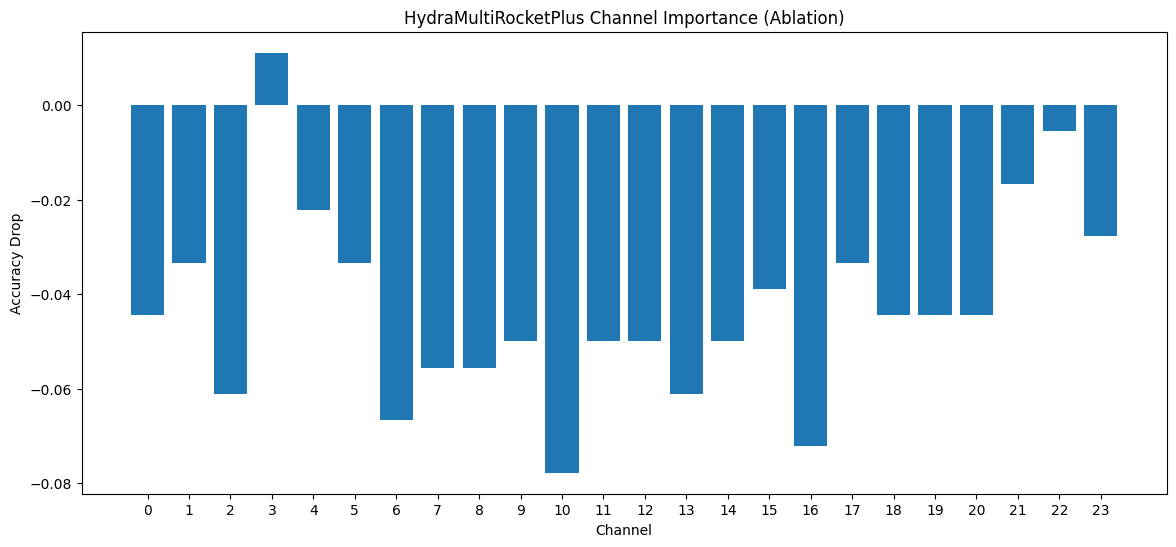


Most important channels:
----------------------------------------
01. Channel 03 | Drop = 0.0111
02. Channel 22 | Drop = -0.0056
03. Channel 21 | Drop = -0.0167
04. Channel 04 | Drop = -0.0222
05. Channel 23 | Drop = -0.0278
06. Channel 05 | Drop = -0.0333
07. Channel 01 | Drop = -0.0333
08. Channel 17 | Drop = -0.0333
09. Channel 15 | Drop = -0.0389
10. Channel 18 | Drop = -0.0444
11. Channel 19 | Drop = -0.0444
12. Channel 20 | Drop = -0.0444
13. Channel 00 | Drop = -0.0444
14. Channel 11 | Drop = -0.0500
15. Channel 12 | Drop = -0.0500
16. Channel 14 | Drop = -0.0500
17. Channel 09 | Drop = -0.0500
18. Channel 08 | Drop = -0.0556
19. Channel 07 | Drop = -0.0556
20. Channel 02 | Drop = -0.0611
21. Channel 13 | Drop = -0.0611
22. Channel 06 | Drop = -0.0667
23. Channel 16 | Drop = -0.0722
24. Channel 10 | Drop = -0.0778


In [10]:
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import torch

# baseline
baseline_acc = acc
print(f"Baseline accuracy: {baseline_acc:.4f}")

channel_scores = []

# validation split
X_valid = X[splits[1]]
y_valid = y_encoded[splits[1]]

device = next(learn.model.parameters()).device

for ch in range(X.shape[1]):

    X_ablate = X_valid.copy()

    # zero-out one channel
    X_ablate[:, ch, :] = 0

    xb = torch.tensor(
        X_ablate,
        dtype=torch.float32
    ).to(device)

    # inference
    with torch.no_grad():

        outputs = learn.model(xb)

        preds = outputs.argmax(dim=1).cpu().numpy()

    # accuracy
    ablated_acc = accuracy_score(y_valid, preds)

    # performance drop
    drop = baseline_acc - ablated_acc

    channel_scores.append(drop)

    print(
        f"Channel {ch:02d} | "
        f"Ablated acc: {ablated_acc:.4f} | "
        f"Drop: {drop:.4f}"
    )


channel_scores = np.array(channel_scores)

plt.figure(figsize=(14,6))

plt.bar(
    np.arange(X.shape[1]),
    channel_scores
)

plt.xlabel("Channel")
plt.ylabel("Accuracy Drop")
plt.title("HydraMultiRocketPlus Channel Importance (Ablation)")
plt.xticks(np.arange(X.shape[1]))

plt.show()



sorted_idx = np.argsort(channel_scores)[::-1]

print("\nMost important channels:")
print("-" * 40)

for rank, ch in enumerate(sorted_idx):

    print(
        f"{rank+1:02d}. "
        f"Channel {ch:02d} | "
        f"Drop = {channel_scores[ch]:.4f}"
    )

*Vrlo zanimljivo*

Ablacijska analiza pokazuje da model ne koristi jednako sve kanale senzora, zapravo neg. acc drop kaže da bi model bolje radio kada bismo uklonili neke kanale...Neki od kanala koji posebno smetaju su:

* kanal 10 (Elbow right, X coordinate)
* kanal 16 (Wrist right, X coordinate)
* kanal 6 (Elbow left, X coordinate)
* kanal 13 (Wrist left, Y coordinate)
* kanal 2 (Hand tip left, Z coordinate)

To sugerira da dio koordinata laktova, zapešća i pomoćnih pokreta unosi redundantne informacije ili šum koji može otežati razlikovanje sličnih gesti.

Jedini kanal koji ima poz drop je **kanal 3 (Hand tip right, X coordinate)**. Uklanjanje tog kanala jedino je dovelo do pada točnosti modela, što sugerira da upravo položaj dominantne ruke nosi ključnu informaciju za razlikovanje gesti poput “thumbs up” i “thumbs down”.

Rezultati pokazuju da HydraMultiRocketPlus za klasifikaciju NATOPS gesti prvenstveno koristi nekoliko najinformativnijih koordinata dominantne ruke, dok velik broj dodatnih kanala nema značajan doprinos ili čak može negativno utjecati na klasifikaciju.


Train shape: (180, 1224)
Valid shape: (180, 1224)

XGBoost accuracy: 0.8389

Classification Report:
              precision    recall  f1-score   support

         1.0       1.00      0.97      0.98        30
         2.0       0.59      0.63      0.61        30
         3.0       0.62      0.60      0.61        30
         4.0       1.00      0.90      0.95        30
         5.0       0.88      1.00      0.94        30
         6.0       0.97      0.93      0.95        30

    accuracy                           0.84       180
   macro avg       0.84      0.84      0.84       180
weighted avg       0.84      0.84      0.84       180



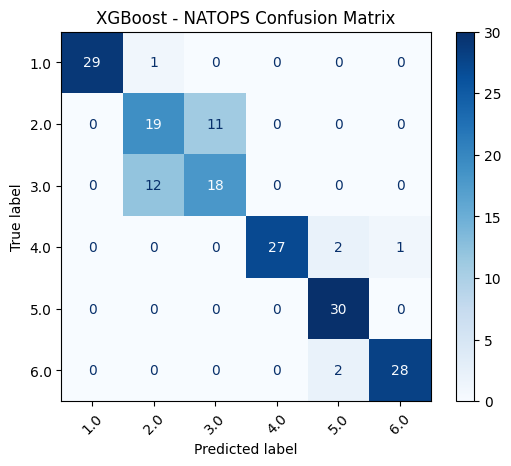

Baseline accuracy: 0.8389
Channel 00 | Permuted acc: 0.8111 | Drop: 0.0278
Channel 01 | Permuted acc: 0.8333 | Drop: 0.0056
Channel 02 | Permuted acc: 0.8389 | Drop: 0.0000
Channel 03 | Permuted acc: 0.8333 | Drop: 0.0056
Channel 04 | Permuted acc: 0.7556 | Drop: 0.0833
Channel 05 | Permuted acc: 0.8333 | Drop: 0.0056
Channel 06 | Permuted acc: 0.8000 | Drop: 0.0389
Channel 07 | Permuted acc: 0.8056 | Drop: 0.0333
Channel 08 | Permuted acc: 0.8389 | Drop: 0.0000
Channel 09 | Permuted acc: 0.8389 | Drop: 0.0000
Channel 10 | Permuted acc: 0.8167 | Drop: 0.0222
Channel 11 | Permuted acc: 0.8389 | Drop: 0.0000
Channel 12 | Permuted acc: 0.8056 | Drop: 0.0333
Channel 13 | Permuted acc: 0.8111 | Drop: 0.0278
Channel 14 | Permuted acc: 0.8389 | Drop: 0.0000
Channel 15 | Permuted acc: 0.8222 | Drop: 0.0167
Channel 16 | Permuted acc: 0.8333 | Drop: 0.0056
Channel 17 | Permuted acc: 0.8444 | Drop: -0.0056
Channel 18 | Permuted acc: 0.7556 | Drop: 0.0833
Channel 19 | Permuted acc: 0.8222 | Drop: 

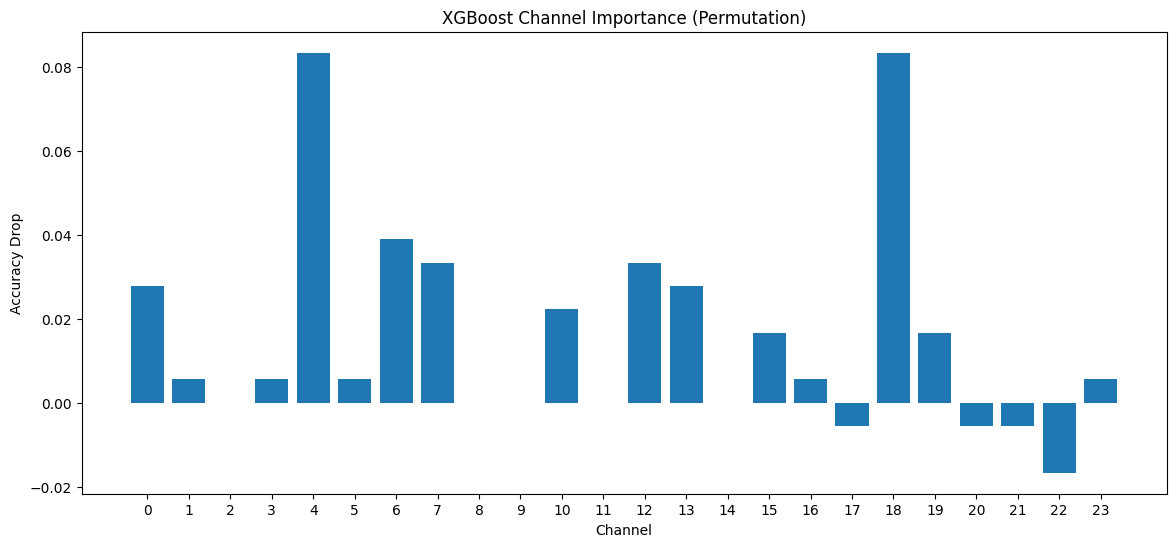


Most important channels:
----------------------------------------
01. Channel 18 | Drop = 0.0833
02. Channel 04 | Drop = 0.0833
03. Channel 06 | Drop = 0.0389
04. Channel 12 | Drop = 0.0333
05. Channel 07 | Drop = 0.0333
06. Channel 00 | Drop = 0.0278
07. Channel 13 | Drop = 0.0278
08. Channel 10 | Drop = 0.0222
09. Channel 19 | Drop = 0.0167
10. Channel 15 | Drop = 0.0167
11. Channel 05 | Drop = 0.0056
12. Channel 03 | Drop = 0.0056
13. Channel 16 | Drop = 0.0056
14. Channel 23 | Drop = 0.0056
15. Channel 01 | Drop = 0.0056
16. Channel 14 | Drop = 0.0000
17. Channel 08 | Drop = 0.0000
18. Channel 09 | Drop = 0.0000
19. Channel 11 | Drop = 0.0000
20. Channel 02 | Drop = 0.0000
21. Channel 20 | Drop = -0.0056
22. Channel 17 | Drop = -0.0056
23. Channel 21 | Drop = -0.0056
24. Channel 22 | Drop = -0.0167


In [11]:
# ============================================
# XGBOOST CLASSIFICATION FOR NATOPS
# ============================================

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

import matplotlib.pyplot as plt
import numpy as np

# ============================================
# PREPARE DATA
# ============================================

# flatten multivariate time series
# [samples, channels, time]
# ->
# [samples, features]

X_flat = X.reshape(X.shape[0], -1)

# train/valid split
X_train = X_flat[splits[0]]
X_valid = X_flat[splits[1]]

y_train = y_encoded[splits[0]]
y_valid = y_encoded[splits[1]]

print("Train shape:", X_train.shape)
print("Valid shape:", X_valid.shape)

# ============================================
# XGBOOST MODEL
# ============================================

xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=7,
    learning_rate=0.05,

    subsample=0.8,
    colsample_bytree=0.8,

    objective="multi:softprob",
    eval_metric="mlogloss",

    random_state=42
)

# ============================================
# TRAIN
# ============================================

xgb_model.fit(X_train, y_train)

# ============================================
# PREDICT
# ============================================

preds = xgb_model.predict(X_valid)

acc = accuracy_score(y_valid, preds)

print(f"\nXGBoost accuracy: {acc:.4f}")

# ============================================
# CLASSIFICATION REPORT
# ============================================

print("\nClassification Report:")
print(
    classification_report(
        y_valid,
        preds,
        target_names=le.classes_
    )
)

# ============================================
# CONFUSION MATRIX
# ============================================

cm = confusion_matrix(y_valid, preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45
)

plt.title("XGBoost - NATOPS Confusion Matrix")
plt.show()

# ============================================
# PERMUTATION IMPORTANCE (CHANNEL LEVEL)
# ============================================

from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt
import numpy as np

# baseline accuracy
baseline_preds = xgb_model.predict(X_valid)
baseline_acc = accuracy_score(y_valid, baseline_preds)

print(f"Baseline accuracy: {baseline_acc:.4f}")

# ============================================
# CHANNEL-WISE PERMUTATION
# ============================================

seq_len = X.shape[2]

channel_importance = []

for ch in range(X.shape[1]):

    X_perm = X_valid.copy()

    # feature indices belonging to this channel
    start = ch * seq_len
    end = (ch + 1) * seq_len

    # permute THIS CHANNEL across samples
    perm_idx = np.random.permutation(X_perm.shape[0])

    X_perm[:, start:end] = X_perm[perm_idx, start:end]

    # predict
    preds = xgb_model.predict(X_perm)

    perm_acc = accuracy_score(y_valid, preds)

    # importance = accuracy drop
    drop = baseline_acc - perm_acc

    channel_importance.append(drop)

    print(
        f"Channel {ch:02d} | "
        f"Permuted acc: {perm_acc:.4f} | "
        f"Drop: {drop:.4f}"
    )

channel_importance = np.array(channel_importance)

# ============================================
# PLOT
# ============================================

plt.figure(figsize=(14,6))

plt.bar(
    np.arange(X.shape[1]),
    channel_importance
)

plt.xlabel("Channel")
plt.ylabel("Accuracy Drop")
plt.title("XGBoost Channel Importance (Permutation)")

plt.xticks(np.arange(X.shape[1]))

plt.show()

# ============================================
# SORTED RESULTS
# ============================================

sorted_idx = np.argsort(channel_importance)[::-1]

print("\nMost important channels:")
print("-" * 40)

for rank, ch in enumerate(sorted_idx):

    print(
        f"{rank+1:02d}. "
        f"Channel {ch:02d} | "
        f"Drop = {channel_importance[ch]:.4f}"
    )

XGB uči drukčije obrace:

* kanal 18 (Wrist right, Z coordinate)
* kanal 4 (Hand tip right, Y coordinate)
* kanal 6 (Elbow left, X coordinate)
* kanal 12 (Elbow right, Z coordinate)
* kanal 7 (Elbow left, Y coordinate)

-> veća važnost položaja ruku i laktova, posebno vertikalnim (Y) i dubinskim (Z) koordinatama, odnosno geometrije položaja tijela tijekom izvođenja geste.

